# 03 — E0 / E1 : baselines supervisées ABSA V2

Ce notebook établit les premières références expérimentales de la V2 :

- **E0** : baseline majoritaire ;
- **E1** : student supervisé XLM-RoBERTa sur le **Gold DEV (500 avis)** ;
- validation croisée multilabel stratifiée à **5 folds** ;
- suivi expérimental avec **MLflow**.

> **Protection du TEST**  
> Le Gold TEST de 200 avis reste strictement gelé et n'est jamais chargé ni utilisé
> pour choisir l'architecture, les hyperparamètres ou les critères d'arrêt.

Le notebook privilégie :
1. la reproductibilité ;
2. la lisibilité du pipeline ;
3. la comparaison E0 → E1 ;
4. une évaluation détaillée par aspect, classe et langue.

## 1. Imports et configuration des chemins

In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
)
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer

c:\Users\youne\miniconda3\envs\mon_projet_ia\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Le notebook est prévu pour être exécuté depuis ABSA-V2/notebooks/
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
GOLD_DIR = DATA_DIR / "gold"
INTERIM_DIR = DATA_DIR / "interim"

FILES = {
    # Données brutes
    "fr_full": RAW_DIR / "df_fr_full.jsonl",
    "en_full": RAW_DIR / "df_en_full.jsonl",
    "amazon_20k": RAW_DIR / "amazon_reviews_20k.csv",

    # Artefacts V1 conservés comme baseline
    "gold_400": GOLD_DIR / "gold_standard_annote.csv",
    "gold_test_v1": GOLD_DIR / "vos_200_avis_manuels_test.csv",
    "pseudo_labels_v1": INTERIM_DIR / "pseudo_labels_fewshot.csv",
    "purified_v1": INTERIM_DIR / "dataset_20k_purifie_v2.csv",

    # Gold V2 officiel
    "gold_v2_700": GOLD_DIR / "gold_v2_700_with_provenance.csv",
    "gold_v2_dev": GOLD_DIR / "gold_v2_dev_500.csv",
    "gold_v2_test": GOLD_DIR / "gold_v2_test_200.csv",
}

for name, path in FILES.items():
    print(f"{name:15} | existe={path.exists()} | {path}")

fr_full         | existe=True | c:\Users\youne\OneDrive\Desktop\ABSA-V2\data\raw\df_fr_full.jsonl
en_full         | existe=True | c:\Users\youne\OneDrive\Desktop\ABSA-V2\data\raw\df_en_full.jsonl
amazon_20k      | existe=True | c:\Users\youne\OneDrive\Desktop\ABSA-V2\data\raw\amazon_reviews_20k.csv
gold_400        | existe=True | c:\Users\youne\OneDrive\Desktop\ABSA-V2\data\gold\gold_standard_annote.csv
gold_test_v1    | existe=True | c:\Users\youne\OneDrive\Desktop\ABSA-V2\data\gold\vos_200_avis_manuels_test.csv
pseudo_labels_v1 | existe=True | c:\Users\youne\OneDrive\Desktop\ABSA-V2\data\interim\pseudo_labels_fewshot.csv
purified_v1     | existe=True | c:\Users\youne\OneDrive\Desktop\ABSA-V2\data\interim\dataset_20k_purifie_v2.csv
gold_v2_700     | existe=True | c:\Users\youne\OneDrive\Desktop\ABSA-V2\data\gold\gold_v2_700_with_provenance.csv
gold_v2_dev     | existe=True | c:\Users\youne\OneDrive\Desktop\ABSA-V2\data\gold\gold_v2_dev_500.csv
gold_v2_test    | existe=True | c:\Users\

## 2. Chargement et contrôles du Gold DEV

Le notebook travaille uniquement sur `gold_v2_dev_500.csv`.

Taxonomie commune aux quatre aspects :

`absent / négatif / neutre / positif`

In [3]:
gold_dev = pd.read_csv(FILES["gold_v2_dev"])
gold_dev.head()

,id,language,text,quality,price,delivery,service
0,fr_0605960,fr,Trop cher\n\nBeaucoup de défaut de fabrication...,négatif,négatif,absent,absent
1,fr_0200494,fr,Top : joli et facile à monter\n\nBien fini Liv...,positif,absent,positif,absent
2,fr_0577352,fr,Très fin et se voit mal\n\nLe disque se voit a...,négatif,absent,absent,absent
3,fr_0212831,fr,Rasoir très pratique\n\nJ’ai un pull que j’aim...,positif,positif,absent,absent
4,en_0295305,en,Satisfied\n\nI received my smiling Apple Watch...,positif,absent,absent,absent


In [4]:
print("Shape :", gold_dev.shape)
print("\nColonnes :")
print(gold_dev.columns.tolist())

print("\nInformations sur le dataset :")
gold_dev.info()

print("\nValeurs manquantes par colonne :")
print(gold_dev.isna().sum())

print("\nNombre de lignes dupliquées :")
print(gold_dev.duplicated().sum())

print("\nNombre de valeurs uniques par colonne :")
for col in gold_dev.columns:
    print(f"{col}: {gold_dev[col].nunique()}")

Shape : (500, 7)

Colonnes :
['id', 'language', 'text', 'quality', 'price', 'delivery', 'service']

Informations sur le dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        500 non-null    object
 1   language  500 non-null    object
 2   text      500 non-null    object
 3   quality   500 non-null    object
 4   price     500 non-null    object
 5   delivery  500 non-null    object
 6   service   500 non-null    object
dtypes: object(7)
memory usage: 27.5+ KB

Valeurs manquantes par colonne :
id          0
language    0
text        0
quality     0
price       0
delivery    0
service     0
dtype: int64

Nombre de lignes dupliquées :
0

Nombre de valeurs uniques par colonne :
id: 500
language: 2
text: 500
quality: 4
price: 4
delivery: 4
service: 4


In [5]:
LABELS = [
    "absent",
    "négatif",
    "neutre",
    "positif",
]

ASPECTS = [
    "quality",
    "price",
    "delivery",
    "service",
]

for aspect in ASPECTS:
    count_invalid = (~gold_dev[aspect].isin(LABELS)).sum()
    print(count_invalid, "valeurs invalides pour l'aspect", aspect)

print("\nLangues :")
print(gold_dev["language"].value_counts())

count_invalid_language = (~gold_dev["language"].isin(["fr", "en"])).sum()
print(count_invalid_language, "valeurs invalides pour la colonne language")

0 valeurs invalides pour l'aspect quality
0 valeurs invalides pour l'aspect price
0 valeurs invalides pour l'aspect delivery
0 valeurs invalides pour l'aspect service

Langues :
language
fr    250
en    250
Name: count, dtype: int64
0 valeurs invalides pour la colonne language


In [6]:
for aspect in ASPECTS:
    print(f"\n--- {aspect.upper()} ---")

    table = pd.crosstab(
        gold_dev["language"],
        gold_dev[aspect],
        margins=True,
        margins_name="Total"
    )

    print(table)


--- QUALITY ---
quality   absent  neutre  négatif  positif  Total
language                                         
en            50      34      103       63    250
fr            54      25       96       75    250
Total        104      59      199      138    500

--- PRICE ---
price     absent  neutre  négatif  positif  Total
language                                         
en           167      30       18       35    250
fr           177      20       21       32    250
Total        344      50       39       67    500

--- DELIVERY ---
delivery  absent  neutre  négatif  positif  Total
language                                         
en           179      20       38       13    250
fr           143      12       63       32    250
Total        322      32      101       45    500

--- SERVICE ---
service   absent  neutre  négatif  positif  Total
language                                         
en           204       3       23       20    250
fr           189      10       24

### Lecture du déséquilibre

L'accuracy seule peut être trompeuse lorsque `absent` domine fortement un aspect.
Le **Macro-F1** sera donc la métrique principale de comparaison E0/E1, complétée
par une analyse par classe et par langue.

## 3. EDA minimale du Gold DEV

In [7]:
n_aspects_present = (gold_dev[ASPECTS] != "absent").sum(axis=1)

aspect_counts = (
    n_aspects_present
    .value_counts()
    .sort_index()
)

aspect_counts

0     11
1    193
2    245
3     50
4      1
Name: count, dtype: int64

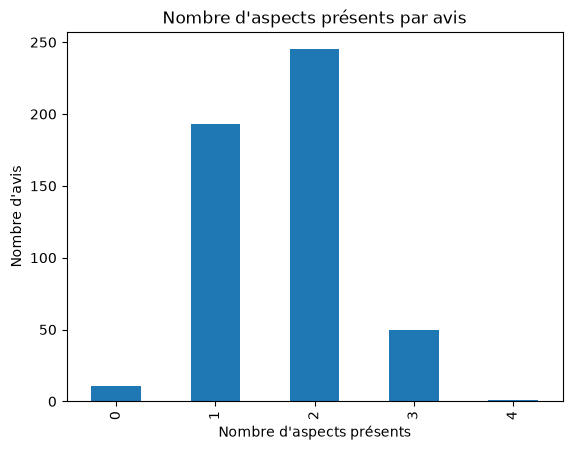

In [8]:
aspect_counts.plot(kind="bar")
plt.title("Nombre d'aspects présents par avis")
plt.xlabel("Nombre d'aspects présents")
plt.ylabel("Nombre d'avis")
plt.show()

In [9]:
text_length_words = (
    gold_dev["text"]
    .str.split()
    .str.len()
)

text_length_words.describe()

count    500.000000
mean      42.506000
std       34.558915
min        4.000000
25%       20.000000
50%       33.000000
75%       54.000000
max      228.000000
Name: text, dtype: float64

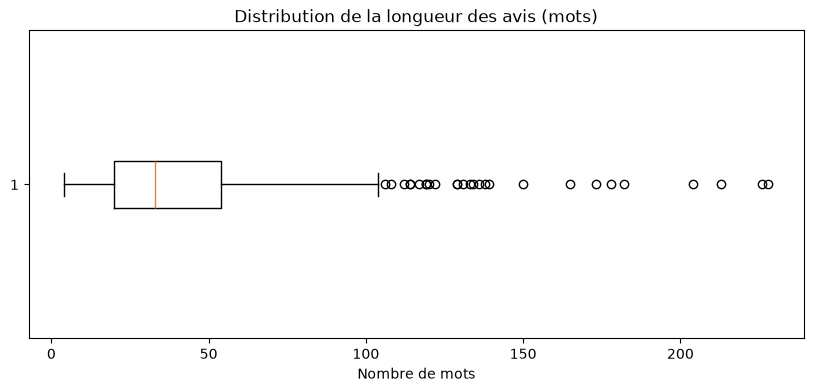

In [10]:
plt.figure(figsize=(10, 4))
plt.boxplot(text_length_words, orientation="horizontal")
plt.title("Distribution de la longueur des avis (mots)")
plt.xlabel("Nombre de mots")
plt.show()

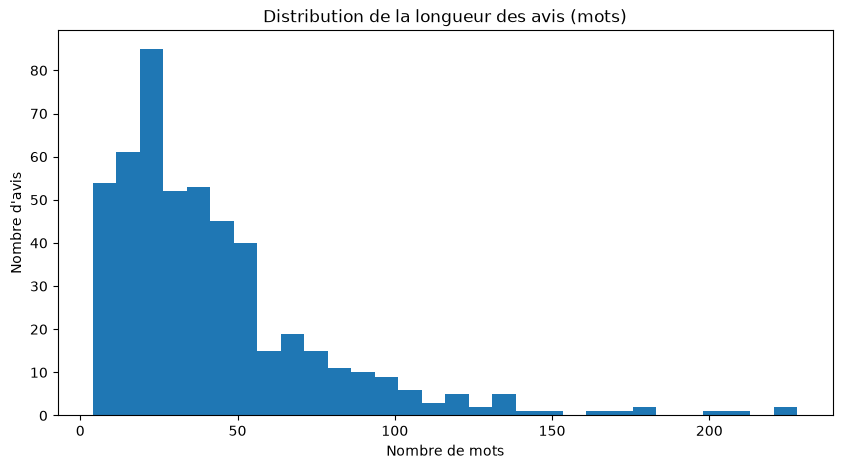

In [11]:
plt.figure(figsize=(10, 5))
plt.hist(text_length_words, bins=30)
plt.title("Distribution de la longueur des avis (mots)")
plt.xlabel("Nombre de mots")
plt.ylabel("Nombre d'avis")
plt.show()

## 4. Protocole de validation croisée

Le Gold TEST reste gelé.

Les 500 avis du Gold DEV sont évalués par **validation croisée multilabel
stratifiée à 5 folds**.

La matrice `y_strat` encode simultanément :

- la langue ;
- les quatre états de chacun des quatre aspects.

Elle sert **uniquement à construire les folds** et n'est jamais fournie au modèle
comme variable d'entrée.

In [12]:
y_strat = pd.get_dummies(
    gold_dev[
        ["language", "quality", "price", "delivery", "service"]
    ],
    columns=["language", "quality", "price", "delivery", "service"]
)

mskf = MultilabelStratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

folds = list(mskf.split(gold_dev, y_strat))

for fold, (train_idx, val_idx) in enumerate(folds, start=1):
    print(
        f"Fold {fold}: "
        f"train={len(train_idx)} | "
        f"validation={len(val_idx)}"
    )

Fold 1: train=401 | validation=99
Fold 2: train=400 | validation=100
Fold 3: train=400 | validation=100
Fold 4: train=398 | validation=102
Fold 5: train=401 | validation=99


In [13]:
# Sanity check des distributions de validation.
for fold, (_, val_idx) in enumerate(folds, start=1):
    val_df = gold_dev.iloc[val_idx]

    print(f"\n{'=' * 60}")
    print(f"FOLD {fold}")
    print(f"{'=' * 60}")

    print("\nLangues :")
    print(val_df["language"].value_counts())

    for aspect in ASPECTS:
        print(f"\n{aspect.upper()}")
        print(
            val_df[aspect]
            .value_counts()
            .reindex(LABELS, fill_value=0)
        )


FOLD 1

Langues :
language
fr    50
en    49
Name: count, dtype: int64

QUALITY
quality
absent     20
négatif    39
neutre     12
positif    28
Name: count, dtype: int64

PRICE
price
absent     69
négatif     7
neutre     10
positif    13
Name: count, dtype: int64

DELIVERY
delivery
absent     64
négatif    20
neutre      6
positif     9
Name: count, dtype: int64

SERVICE
service
absent     78
négatif     9
neutre      3
positif     9
Name: count, dtype: int64

FOLD 2

Langues :
language
fr    50
en    50
Name: count, dtype: int64

QUALITY
quality
absent     21
négatif    41
neutre     11
positif    27
Name: count, dtype: int64

PRICE
price
absent     68
négatif     8
neutre     10
positif    14
Name: count, dtype: int64

DELIVERY
delivery
absent     64
négatif    20
neutre      7
positif     9
Name: count, dtype: int64

SERVICE
service
absent     80
négatif     9
neutre      2
positif     9
Name: count, dtype: int64

FOLD 3

Langues :
language
fr    50
en    50
Name: count, dtype: in

# E0 — Baseline majoritaire

Pour chaque fold et chaque aspect :

1. la classe majoritaire est calculée uniquement sur le train du fold ;
2. cette classe est prédite pour tous les exemples de validation ;
3. Accuracy et Macro-F1 sont mesurés.

E0 constitue le plancher naïf à dépasser par E1.

In [14]:
e0_fold_results = []

for fold, (train_idx, val_idx) in enumerate(folds, start=1):
    train_df = gold_dev.iloc[train_idx]
    val_df = gold_dev.iloc[val_idx]

    for aspect in ASPECTS:
        majority_class = train_df[aspect].value_counts().index[0]

        y_true = val_df[aspect]
        y_pred = [majority_class] * len(val_df)

        accuracy = accuracy_score(y_true, y_pred)

        macro_f1 = f1_score(
            y_true,
            y_pred,
            labels=LABELS,
            average="macro",
            zero_division=0
        )

        e0_fold_results.append({
            "fold": fold,
            "aspect": aspect,
            "majority_class": majority_class,
            "accuracy": accuracy,
            "macro_f1": macro_f1,
        })

baseline_results = pd.DataFrame(e0_fold_results)
display(baseline_results)

,fold,aspect,majority_class,accuracy,macro_f1
0,1,quality,négatif,0.393939,0.141304
1,1,price,absent,0.696970,0.205357
2,1,delivery,absent,0.646465,0.196319
3,1,service,absent,0.787879,0.220339
4,2,quality,négatif,0.410000,0.145390
5,2,price,absent,0.680000,0.202381
6,2,delivery,absent,0.640000,0.195122
7,2,service,absent,0.800000,0.222222
8,3,quality,négatif,0.390000,0.140288
9,3,price,absent,0.690000,0.204142


In [15]:
baseline_summary = (
    baseline_results
    .groupby("aspect")[["accuracy", "macro_f1"]]
    .agg(["mean", "std"])
)

display(baseline_summary)

accuracy            macro_f1          
              mean       std      mean       std
aspect                                          
delivery  0.643958  0.009869  0.195847  0.001828
price     0.687963  0.009218  0.203778  0.001619
quality   0.397908  0.012394  0.142300  0.003168
service   0.785994  0.008746  0.220039  0.001366

### Conclusion E0

La baseline majoritaire met en évidence l'effet du déséquilibre des classes.
L'accuracy est particulièrement favorable aux aspects dominés par `absent`,
alors que le Macro-F1 révèle l'incapacité d'un prédicteur constant à reconnaître
les autres classes.

Le **Macro-F1** est donc retenu comme métrique principale pour E1, avec analyse
complémentaire par aspect, classe et langue.

## 5. Tracking MLflow local

In [16]:
MLFLOW_DB = PROJECT_ROOT / "mlflow.db"

mlflow.set_tracking_uri(
    f"sqlite:///{MLFLOW_DB.as_posix()}"
)

print("MLflow tracking URI :", mlflow.get_tracking_uri())

MLflow tracking URI : sqlite:///c:/Users/youne/OneDrive/Desktop/ABSA-V2/mlflow.db


In [17]:
mlflow.set_experiment("ABSA_V2_E0")

with mlflow.start_run(run_name="baseline_majoritaire_5fold"):
    mlflow.log_params({
        "strategy": "majority_class",
        "n_folds": 5,
        "dataset": "gold_dev_500",
        "test_used": False,
    })

    for aspect in ASPECTS:
        mlflow.log_metric(
            f"{aspect}_accuracy_mean",
            baseline_summary.loc[aspect, ("accuracy", "mean")]
        )
        mlflow.log_metric(
            f"{aspect}_accuracy_std",
            baseline_summary.loc[aspect, ("accuracy", "std")]
        )
        mlflow.log_metric(
            f"{aspect}_macro_f1_mean",
            baseline_summary.loc[aspect, ("macro_f1", "mean")]
        )
        mlflow.log_metric(
            f"{aspect}_macro_f1_std",
            baseline_summary.loc[aspect, ("macro_f1", "std")]
        )

# E1 — Student supervisé sur Gold DEV

## Objectif

Entraîner un **XLM-RoBERTa-base partagé** avec quatre têtes de classification
indépendantes :

- `quality`
- `price`
- `delivery`
- `service`

Chaque tête prédit une classe parmi :

`absent / négatif / neutre / positif`

Le modèle est évalué avec exactement les mêmes 5 folds que E0.

In [18]:
LABEL2ID = {
    "absent": 0,
    "négatif": 1,
    "neutre": 2,
    "positif": 3,
}

ID2LABEL = {v: k for k, v in LABEL2ID.items()}

gold_dev_encoded = gold_dev.copy()

for aspect in ASPECTS:
    gold_dev_encoded[aspect] = gold_dev_encoded[aspect].map(LABEL2ID)

assert gold_dev_encoded[ASPECTS].isna().sum().sum() == 0, (
    "Au moins un label n'a pas pu être encodé."
)

In [19]:
MODEL_NAME = "FacebookAI/xlm-roberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer chargé :", MODEL_NAME)
print("Taille du vocabulaire :", tokenizer.vocab_size)

Tokenizer chargé : FacebookAI/xlm-roberta-base
Taille du vocabulaire : 250002


### Choix de la longueur maximale

In [20]:
token_lengths = gold_dev_encoded["text"].apply(
    lambda text: len(
        tokenizer(
            text,
            add_special_tokens=True,
            truncation=False
        )["input_ids"]
    )
)

print(token_lengths.describe())

print("\nPercentiles :")
print(token_lengths.quantile([0.90, 0.95, 0.99]))

print("\nNombre d'avis > 128 tokens :", (token_lengths > 128).sum())
print("Nombre d'avis > 256 tokens :", (token_lengths > 256).sum())
print("Longueur maximale :", token_lengths.max())

count    500.000000
mean      60.120000
std       46.834566
min        8.000000
25%       28.000000
50%       48.000000
75%       77.000000
max      343.000000
Name: text, dtype: float64

Percentiles :
0.90    117.10
0.95    150.05
0.99    249.14
Name: text, dtype: float64

Nombre d'avis > 128 tokens : 39
Nombre d'avis > 256 tokens : 5
Longueur maximale : 343


`MAX_LENGTH = 256` est retenu pour E1.

Ce choix couvre la quasi-totalité du Gold DEV tout en limitant la mémoire GPU.
Les quelques avis dépassant 256 tokens seront tronqués ; ce compromis devra être
réévalué uniquement si les résultats montrent un problème associé aux avis longs.

## 6. Dataset et DataLoader

Un exemple produit par `ABSADataset` contient :

- `input_ids` : `[L]`
- `attention_mask` : `[L]`
- `labels` : `[4]`, une classe par aspect.

Après batching avec `BATCH_SIZE = 8` :

- `input_ids` : `[B, L]`
- `attention_mask` : `[B, L]`
- `labels` : `[B, 4]`

In [21]:
MAX_LENGTH = 256
BATCH_SIZE = 8


class ABSADataset(Dataset):
    """
    Dataset PyTorch pour l'ABSA à quatre aspects.

    Chaque élément retourne :
    - input_ids: Tensor [max_length]
    - attention_mask: Tensor [max_length]
    - labels: Tensor [4], dans l'ordre défini par ASPECTS.
    """

    def __init__(self, dataframe, tokenizer, max_length):
        self.dataframe = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        encoding = self.tokenizer(
            row["text"],
            max_length=self.max_length,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )

        labels = torch.tensor(
            [row[aspect] for aspect in ASPECTS],
            dtype=torch.long
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": labels,
        }

### Sanity check — Dataset et batching

In [22]:
dataset_test = ABSADataset(
    gold_dev_encoded,
    tokenizer,
    MAX_LENGTH
)

sample = dataset_test[0]

print("input_ids      :", sample["input_ids"].shape)
print("attention_mask :", sample["attention_mask"].shape)
print("labels         :", sample["labels"].shape)

print("\nLabels décodés :")
for aspect, label_id in zip(ASPECTS, sample["labels"]):
    print(f"{aspect:8} -> {ID2LABEL[label_id.item()]}")

input_ids      : torch.Size([256])
attention_mask : torch.Size([256])
labels         : torch.Size([4])

Labels décodés :
quality  -> négatif
price    -> négatif
delivery -> absent
service  -> absent


In [23]:
dataloader_test = DataLoader(
    dataset_test,
    batch_size=BATCH_SIZE,
    shuffle=True
)

batch = next(iter(dataloader_test))

print("input_ids      :", batch["input_ids"].shape)
print("attention_mask :", batch["attention_mask"].shape)
print("labels         :", batch["labels"].shape)

input_ids      : torch.Size([8, 256])
attention_mask : torch.Size([8, 256])
labels         : torch.Size([8, 4])


## 7. Architecture du student E1

Flux principal :

```text
TEXT
  ↓
Tokenizer
  ↓
input_ids + attention_mask
  ↓
XLM-R
  ↓
last_hidden_state [B, L, 768]
  ↓
premier token <s> [B, 768]
  ↓
Dropout
  ↓
4 têtes indépendantes Linear(768, 4)
  ↓
4 ensembles de logits [B, 4]
```

Chaque tête possède ses propres poids, mais les quatre partagent le même encodeur
XLM-R. Les quatre CrossEntropyLoss sont ensuite moyennées.

In [24]:
class ABSAClassifier(nn.Module):
    """
    Student ABSA basé sur un encodeur XLM-R partagé.

    Architecture :
    - encodeur Transformer partagé ;
    - représentation de séquence = premier token spécial <s> ;
    - dropout ;
    - une tête Linear indépendante par aspect.

    Sortie :
        dict[str, Tensor] où chaque Tensor a la forme
        [batch_size, num_labels].
    """

    def __init__(self, model_name, num_labels=4):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(0.1)

        self.classifiers = nn.ModuleDict({
            aspect: nn.Linear(hidden_size, num_labels)
            for aspect in ASPECTS
        })

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # XLM-R utilise <s> en première position ; on l'emploie ici
        # comme représentation globale de la séquence.
        sequence_embedding = outputs.last_hidden_state[:, 0, :]
        sequence_embedding = self.dropout(sequence_embedding)

        logits = {
            aspect: classifier(sequence_embedding)
            for aspect, classifier in self.classifiers.items()
        }

        return logits

### Sanity check — Forward et loss

In [25]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = ABSAClassifier(MODEL_NAME).to(device)
model.eval()

batch = next(iter(dataloader_test))

input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
labels = batch["labels"].to(device)

with torch.no_grad():
    logits = model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

print("Device :", device)

for aspect in ASPECTS:
    print(aspect, ":", logits[aspect].shape)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2825.52it/s]
[transformers] XLMRobertaModel LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device : cuda
quality : torch.Size([8, 4])
price : torch.Size([8, 4])
delivery : torch.Size([8, 4])
service : torch.Size([8, 4])


In [26]:
criterion = nn.CrossEntropyLoss()

losses = {
    aspect: criterion(
        logits[aspect],
        labels[:, i]
    )
    for i, aspect in enumerate(ASPECTS)
}

total_loss = sum(losses.values()) / len(ASPECTS)

for aspect, loss_value in losses.items():
    print(f"{aspect:8} loss : {loss_value.item():.4f}")

print(f"\nTotal loss : {total_loss.item():.4f}")

quality  loss : 1.2481
price    loss : 1.1343
delivery loss : 1.8602
service  loss : 1.8541

Total loss : 1.5242


In [27]:
del model

if torch.cuda.is_available():
    torch.cuda.empty_cache()

## 8. Fonctions d'entraînement et d'évaluation

Pour chaque batch d'entraînement :

1. charger le batch ;
2. envoyer les tenseurs sur le device ;
3. `optimizer.zero_grad()` ;
4. forward ;
5. calculer une CrossEntropy par aspect ;
6. moyenner les quatre losses ;
7. `loss.backward()` ;
8. `optimizer.step()` ;
9. accumuler la loss.

Validation :

`forward + loss + métriques`, **sans backward ni mise à jour des paramètres**.

In [28]:
SEED = 42
EPOCHS = 3
LEARNING_RATE = 2e-5


def set_seed(seed):
    """Fixe les principales sources d'aléatoire utilisées dans E1."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def train_one_epoch(model, train_loader, optimizer, criterion, device):
    """
    Entraîne le modèle pendant un epoch complet.

    Retourne :
        loss moyenne pondérée par le nombre réel d'exemples.
    """
    model.train()

    total_loss = 0.0
    total_samples = 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        losses = [
            criterion(logits[aspect], labels[:, i])
            for i, aspect in enumerate(ASPECTS)
        ]

        loss = sum(losses) / len(losses)

        loss.backward()
        optimizer.step()

        batch_size = input_ids.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    return total_loss / total_samples


def evaluate(model, val_loader, criterion, device):
    """
    Évalue le modèle sans modifier ses paramètres.

    Retourne :
        val_loss : loss moyenne sur la validation ;
        metrics  : Accuracy et Macro-F1 par aspect ;
        y_true   : labels Gold accumulés par aspect ;
        y_pred   : classes prédites accumulées par aspect.
    """
    model.eval()

    total_loss = 0.0
    total_samples = 0

    y_true = {aspect: [] for aspect in ASPECTS}
    y_pred = {aspect: [] for aspect in ASPECTS}

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            losses = [
                criterion(logits[aspect], labels[:, i])
                for i, aspect in enumerate(ASPECTS)
            ]

            loss = sum(losses) / len(losses)

            batch_size = input_ids.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

            for i, aspect in enumerate(ASPECTS):
                predictions = torch.argmax(
                    logits[aspect],
                    dim=1
                )

                y_true[aspect].extend(
                    labels[:, i].cpu().tolist()
                )

                y_pred[aspect].extend(
                    predictions.cpu().tolist()
                )

    metrics = {}

    for aspect in ASPECTS:
        metrics[aspect] = {
            "accuracy": accuracy_score(
                y_true[aspect],
                y_pred[aspect]
            ),
            "macro_f1": f1_score(
                y_true[aspect],
                y_pred[aspect],
                labels=[0, 1, 2, 3],
                average="macro",
                zero_division=0
            )
        }

    val_loss = total_loss / total_samples

    return val_loss, metrics, y_true, y_pred

## 9. E1 — Validation croisée 5-fold

Chaque fold repart d'un **modèle XLM-R neuf** et d'un **optimizer neuf**.

C'est indispensable : réutiliser les poids d'un fold précédent créerait une
contamination entre folds, car un exemple de validation d'un fold peut avoir
appartenu au train d'un autre fold.

Les métriques retenues pour l'agrégation sont celles de l'**epoch 3**, durée
fixée à l'avance pour cette baseline.

In [29]:
criterion = nn.CrossEntropyLoss()

e1_fold_results = []
oof_parts = []

mlflow.set_experiment("ABSA_V2_E1")

with mlflow.start_run(run_name="xlm_roberta_base_5fold"):

    mlflow.log_params({
        "model_name": MODEL_NAME,
        "n_folds": 5,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "max_length": MAX_LENGTH,
        "optimizer": "AdamW",
        "loss": "mean_4_cross_entropy",
        "class_weights": False,
        "seed": SEED,
        "dataset": "gold_dev_500",
        "test_used": False
    })

    for fold_idx, (train_idx, val_idx) in enumerate(folds, start=1):

        print(f"\n{'=' * 60}")
        print(f"FOLD {fold_idx}/5")
        print(f"{'=' * 60}")

        fold_seed = SEED + fold_idx
        set_seed(fold_seed)

        train_df = (
            gold_dev_encoded
            .iloc[train_idx]
            .reset_index(drop=True)
        )

        val_df = (
            gold_dev_encoded
            .iloc[val_idx]
            .reset_index(drop=True)
        )

        train_dataset = ABSADataset(
            train_df,
            tokenizer,
            MAX_LENGTH
        )

        val_dataset = ABSADataset(
            val_df,
            tokenizer,
            MAX_LENGTH
        )

        generator = torch.Generator()
        generator.manual_seed(fold_seed)

        train_loader = DataLoader(
            train_dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            generator=generator
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False
        )

        # Modèle et optimizer neufs pour garantir l'indépendance du fold.
        model = ABSAClassifier(MODEL_NAME).to(device)

        optimizer = AdamW(
            model.parameters(),
            lr=LEARNING_RATE
        )

        with mlflow.start_run(
            run_name=f"fold_{fold_idx}",
            nested=True
        ):

            mlflow.log_param("fold", fold_idx)
            mlflow.log_param("seed", fold_seed)
            mlflow.log_param("train_size", len(train_df))
            mlflow.log_param("val_size", len(val_df))

            final_metrics = None
            final_y_true = None
            final_y_pred = None

            for epoch in range(1, EPOCHS + 1):

                train_loss = train_one_epoch(
                    model,
                    train_loader,
                    optimizer,
                    criterion,
                    device
                )

                (
                    val_loss,
                    metrics,
                    y_true,
                    y_pred
                ) = evaluate(
                    model,
                    val_loader,
                    criterion,
                    device
                )

                mean_macro_f1 = np.mean([
                    metrics[aspect]["macro_f1"]
                    for aspect in ASPECTS
                ])

                print(
                    f"Epoch {epoch}/{EPOCHS} | "
                    f"train_loss={train_loss:.4f} | "
                    f"val_loss={val_loss:.4f} | "
                    f"mean_macro_f1={mean_macro_f1:.4f}"
                )

                mlflow.log_metric(
                    "train_loss",
                    train_loss,
                    step=epoch
                )

                mlflow.log_metric(
                    "val_loss",
                    val_loss,
                    step=epoch
                )

                mlflow.log_metric(
                    "mean_macro_f1",
                    mean_macro_f1,
                    step=epoch
                )

                for aspect in ASPECTS:
                    mlflow.log_metric(
                        f"{aspect}_accuracy",
                        metrics[aspect]["accuracy"],
                        step=epoch
                    )

                    mlflow.log_metric(
                        f"{aspect}_macro_f1",
                        metrics[aspect]["macro_f1"],
                        step=epoch
                    )

                final_metrics = metrics
                final_y_true = y_true
                final_y_pred = y_pred

            for aspect in ASPECTS:
                e1_fold_results.append({
                    "fold": fold_idx,
                    "aspect": aspect,
                    "accuracy": final_metrics[aspect]["accuracy"],
                    "macro_f1": final_metrics[aspect]["macro_f1"]
                })

            # Les prédictions OOF de l'epoch final permettent l'analyse
            # globale par classe et par langue sans toucher au Gold TEST.
            metadata_cols = [
                col for col in ["id", "text", "language"]
                if col in val_df.columns
            ]

            fold_oof = val_df[metadata_cols].copy()
            fold_oof["fold"] = fold_idx

            for aspect in ASPECTS:
                fold_oof[f"{aspect}_true"] = final_y_true[aspect]
                fold_oof[f"{aspect}_pred"] = final_y_pred[aspect]

            oof_parts.append(fold_oof)

        del model
        del optimizer

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # Agrégats E1 disponibles directement dans le run parent MLflow.
    e1_results = pd.DataFrame(e1_fold_results)

    e1_summary = (
        e1_results
        .groupby("aspect")
        .agg({
            "accuracy": ["mean", "std"],
            "macro_f1": ["mean", "std"]
        })
    )

    for aspect in ASPECTS:
        mlflow.log_metric(
            f"{aspect}_accuracy_mean",
            e1_summary.loc[aspect, ("accuracy", "mean")]
        )
        mlflow.log_metric(
            f"{aspect}_accuracy_std",
            e1_summary.loc[aspect, ("accuracy", "std")]
        )
        mlflow.log_metric(
            f"{aspect}_macro_f1_mean",
            e1_summary.loc[aspect, ("macro_f1", "mean")]
        )
        mlflow.log_metric(
            f"{aspect}_macro_f1_std",
            e1_summary.loc[aspect, ("macro_f1", "std")]
        )

    overall_macro_f1_mean = e1_summary[("macro_f1", "mean")].mean()

    mlflow.log_metric(
        "overall_macro_f1_mean",
        overall_macro_f1_mean
    )

oof_predictions = pd.concat(
    oof_parts,
    ignore_index=True
)

print("\nOOF rows :", len(oof_predictions))


FOLD 1/5


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4719.84it/s]
[transformers] XLMRobertaModel LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/3 | train_loss=1.1323 | val_loss=1.0155 | mean_macro_f1=0.1928
Epoch 2/3 | train_loss=0.9918 | val_loss=0.9194 | mean_macro_f1=0.2080
Epoch 3/3 | train_loss=0.8926 | val_loss=0.7709 | mean_macro_f1=0.3252

FOLD 2/5


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3447.70it/s]
[transformers] XLMRobertaModel LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/3 | train_loss=1.0846 | val_loss=0.9456 | mean_macro_f1=0.2270
Epoch 2/3 | train_loss=0.9340 | val_loss=0.8369 | mean_macro_f1=0.3200
Epoch 3/3 | train_loss=0.8086 | val_loss=0.7484 | mean_macro_f1=0.3844

FOLD 3/5


...

Epoch 1/3 | train_loss=1.1196 | val_loss=0.9964 | mean_macro_f1=0.1892
Epoch 2/3 | train_loss=0.9762 | val_loss=0.8781 | mean_macro_f1=0.3028
Epoch 3/3 | train_loss=0.8669 | val_loss=0.8237 | mean_macro_f1=0.3301

FOLD 4/5


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2420.56it/s]
[transformers] XLMRobertaModel LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/3 | train_loss=1.1631 | val_loss=0.9828 | mean_macro_f1=0.2219
Epoch 2/3 | train_loss=0.9837 | val_loss=0.8769 | mean_macro_f1=0.2767
Epoch 3/3 | train_loss=0.8576 | val_loss=0.8164 | mean_macro_f1=0.3358

FOLD 5/5


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2653.69it/s]
[transformers] XLMRobertaModel LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/3 | train_loss=1.1254 | val_loss=1.0768 | mean_macro_f1=0.1889
Epoch 2/3 | train_loss=1.0097 | val_loss=0.9743 | mean_macro_f1=0.2028
Epoch 3/3 | train_loss=0.9098 | val_loss=0.9383 | mean_macro_f1=0.2833

OOF rows : 500


## 10. Résumé cross-validation E1

In [30]:
display(e1_results)
display(e1_summary)

overall_macro_f1_mean = e1_summary[("macro_f1", "mean")].mean()
print(f"Macro-F1 moyenne sur les 4 aspects : {overall_macro_f1_mean:.4f}")

,fold,aspect,accuracy,macro_f1
0,1,quality,0.515152,0.370807
1,1,price,0.737374,0.314286
2,1,delivery,0.767677,0.395384
3,1,service,0.787879,0.220339
4,2,quality,0.520000,0.381184
5,2,price,0.800000,0.406446
6,2,delivery,0.750000,0.434286
7,2,service,0.820000,0.315628
8,3,quality,0.560000,0.410489
9,3,price,0.720000,0.297326


accuracy            macro_f1          
              mean       std      mean       std
aspect                                          
delivery  0.752089  0.012382  0.389112  0.030596
price     0.729966  0.044980  0.298827  0.073890
quality   0.547491  0.054353  0.400743  0.057464
service   0.785954  0.022396  0.238322  0.043237

Macro-F1 moyenne sur les 4 aspects : 0.3318


## 11. Évaluation détaillée OOF

Les prédictions **out-of-fold (OOF)** regroupent les prédictions obtenues lorsque
chaque avis se trouvait dans le fold de validation.

Elles permettent d'analyser E1 sur l'ensemble du Gold DEV sans entraîner ni
évaluer sur le Gold TEST.

Les diagnostics suivants complètent le Macro-F1 moyen :

- F1 par classe ;
- performance FR vs EN ;
- présence `absent` vs `présent` ;
- sentiment conditionnel sur les aspects réellement présents ;
- exact match des quatre aspects ;
- matrices de confusion.

In [31]:
# F1 par classe et par aspect.
per_class_rows = []

for aspect in ASPECTS:
    report = classification_report(
        oof_predictions[f"{aspect}_true"],
        oof_predictions[f"{aspect}_pred"],
        labels=[0, 1, 2, 3],
        target_names=[ID2LABEL[i] for i in range(4)],
        output_dict=True,
        zero_division=0
    )

    for label in LABELS:
        per_class_rows.append({
            "aspect": aspect,
            "class": label,
            "precision": report[label]["precision"],
            "recall": report[label]["recall"],
            "f1": report[label]["f1-score"],
            "support": report[label]["support"],
        })

per_class_metrics = pd.DataFrame(per_class_rows)
display(per_class_metrics)

,aspect,class,precision,recall,f1,support
0,quality,absent,0.594937,0.451923,0.513661,104.0
1,quality,négatif,0.525680,0.874372,0.656604,199.0
2,quality,neutre,0.000000,0.000000,0.000000,59.0
3,quality,positif,0.588889,0.384058,0.464912,138.0
4,price,absent,0.745098,0.994186,0.851806,344.0
5,price,négatif,0.000000,0.000000,0.000000,39.0
6,price,neutre,0.000000,0.000000,0.000000,50.0
7,price,positif,0.575000,0.343284,0.429907,67.0
8,delivery,absent,0.793194,0.940994,0.860795,322.0
9,delivery,négatif,0.615385,0.712871,0.660550,101.0


In [32]:
# Macro-F1 par langue et par aspect.
language_rows = []

for language in ["fr", "en"]:
    subset = oof_predictions[
        oof_predictions["language"] == language
    ]

    for aspect in ASPECTS:
        language_rows.append({
            "language": language,
            "aspect": aspect,
            "macro_f1": f1_score(
                subset[f"{aspect}_true"],
                subset[f"{aspect}_pred"],
                labels=[0, 1, 2, 3],
                average="macro",
                zero_division=0
            )
        })

language_metrics = pd.DataFrame(language_rows)
display(language_metrics)

,language,aspect,macro_f1
0,fr,quality,0.440651
1,fr,price,0.315977
2,fr,delivery,0.393077
3,fr,service,0.251152
4,en,quality,0.366184
5,en,price,0.323998
6,en,delivery,0.378589
7,en,service,0.224670


In [33]:
# Diagnostic présence vs sentiment conditionnel.
diagnostic_rows = []

for aspect in ASPECTS:
    y_true = oof_predictions[f"{aspect}_true"]
    y_pred = oof_predictions[f"{aspect}_pred"]

    # Présence : absent=0, toute autre classe=1.
    presence_true = (y_true != LABEL2ID["absent"]).astype(int)
    presence_pred = (y_pred != LABEL2ID["absent"]).astype(int)

    presence_macro_f1 = f1_score(
        presence_true,
        presence_pred,
        average="macro",
        zero_division=0
    )

    # Sentiment seulement sur les exemples Gold réellement présents.
    present_mask = y_true != LABEL2ID["absent"]

    sentiment_macro_f1 = f1_score(
        y_true[present_mask],
        y_pred[present_mask],
        labels=[
            LABEL2ID["négatif"],
            LABEL2ID["neutre"],
            LABEL2ID["positif"],
        ],
        average="macro",
        zero_division=0
    )

    diagnostic_rows.append({
        "aspect": aspect,
        "presence_macro_f1": presence_macro_f1,
        "sentiment_macro_f1_given_present": sentiment_macro_f1,
    })

diagnostic_metrics = pd.DataFrame(diagnostic_rows)
display(diagnostic_metrics)

,aspect,presence_macro_f1,sentiment_macro_f1_given_present
0,quality,0.702363,0.403024
1,price,0.623872,0.144654
2,delivery,0.764857,0.255699
3,service,0.467101,0.026667


In [34]:
# Exact match : les quatre aspects doivent être corrects simultanément.
exact_match_mask = np.ones(
    len(oof_predictions),
    dtype=bool
)

for aspect in ASPECTS:
    exact_match_mask &= (
        oof_predictions[f"{aspect}_true"].to_numpy()
        ==
        oof_predictions[f"{aspect}_pred"].to_numpy()
    )

exact_match = exact_match_mask.mean()

print(f"Exact match sur les 4 aspects : {exact_match:.4f}")

Exact match sur les 4 aspects : 0.2260


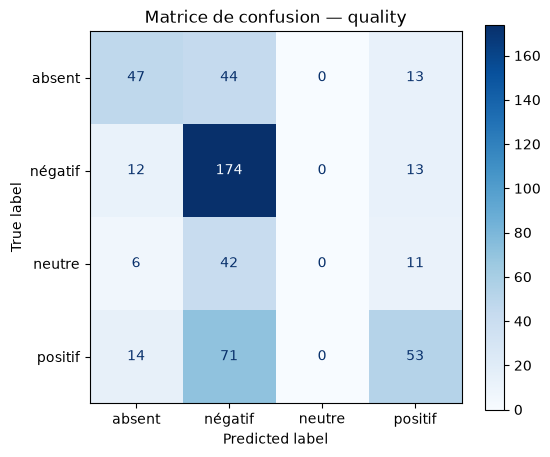

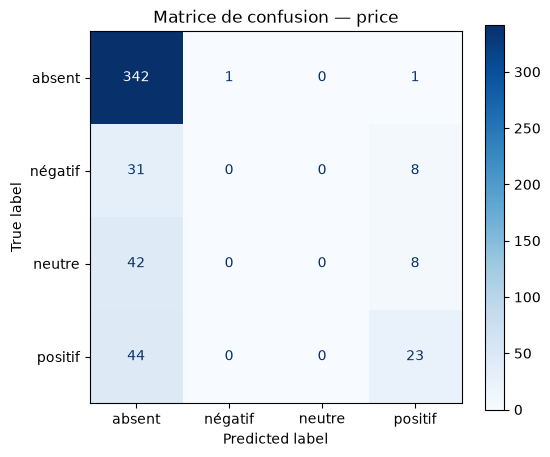

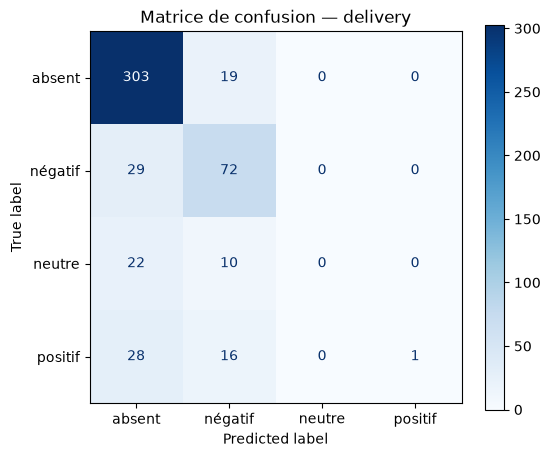

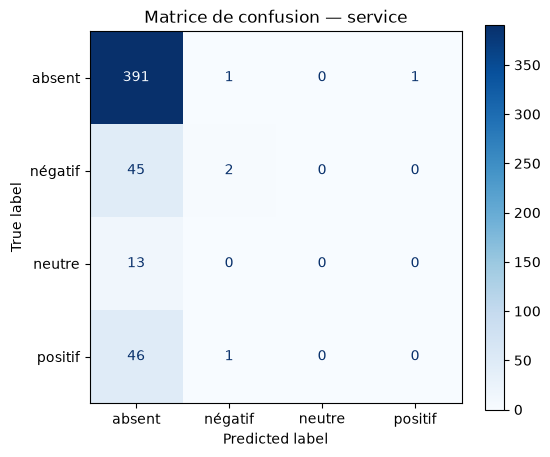

In [35]:
# Matrices de confusion par aspect.
for aspect in ASPECTS:
    fig, ax = plt.subplots(figsize=(6, 5))

    ConfusionMatrixDisplay.from_predictions(
        oof_predictions[f"{aspect}_true"],
        oof_predictions[f"{aspect}_pred"],
        labels=[0, 1, 2, 3],
        display_labels=[ID2LABEL[i] for i in range(4)],
        cmap="Blues",
        values_format="d",
        ax=ax,
    )

    ax.set_title(f"Matrice de confusion — {aspect}")
    plt.show()

## Conclusion E1

L'expérience E1 établit une première baseline Transformer supervisée pour ABSA V2 à partir du seul **Gold DEV de 500 avis**, sans utiliser le Gold TEST, qui reste strictement gelé conformément au protocole expérimental. Le modèle repose sur **XLM-RoBERTa-base comme encodeur multilingue partagé**, avec quatre têtes de classification indépendantes correspondant aux aspects `quality`, `price`, `delivery` et `service`, chacune prédisant les quatre états `absent / négatif / neutre / positif`.

La validation croisée multilabel stratifiée à 5 folds montre qu'E1 dépasse nettement la baseline majoritaire E0. Le Macro-F1 moyen atteint environ **0,40 pour Quality**, **0,30 pour Price**, **0,39 pour Delivery** et **0,24 pour Service**. Le gain par rapport à E0 confirme qu'un encodeur Transformer fine-tuné sur le Gold apprend des représentations utiles malgré le faible volume de données disponibles.

Les résultats restent néanmoins très hétérogènes selon les aspects et les classes. `Quality` et `Delivery` sont les aspects les mieux appris, alors que `Service` reste nettement plus difficile. L'analyse par classe montre surtout une faiblesse importante sur les classes rares, en particulier le **neutre**, dont le F1 est nul ou quasi nul sur plusieurs aspects. `Price/négatif` reste également très difficile. Ce comportement est cohérent avec le faible nombre d'exemples disponibles pour certaines combinaisons aspect × sentiment et confirme que le Macro-F1 global ne suffit pas à lui seul pour juger la qualité du modèle.

L'analyse complémentaire distingue également deux difficultés différentes : le modèle apprend mieux à détecter **si un aspect est présent ou absent** qu'à déterminer précisément son **sentiment conditionnel** lorsqu'il est présent. Cette différence est particulièrement forte pour `Service`, ce qui indique que le principal problème n'est pas uniquement la détection de l'aspect, mais aussi l'apprentissage de sa polarité fine.

L'**exact match** sur les quatre aspects reste faible, autour de **22,6 %**, ce qui rappelle qu'une prédiction correcte au niveau d'un aspect ne garantit pas encore une analyse complète correcte de l'avis. Les matrices de confusion, les résultats par langue et les métriques par classe doivent donc rester des diagnostics de référence pour les prochaines expériences, conformément au protocole V2 qui impose une attention particulière au neutre, aux aspects rares et aux écarts FR/EN. :contentReference[oaicite:0]{index=0}

E1 remplit néanmoins son objectif principal : fournir une **baseline supervisée reproductible et suffisamment informative** pour évaluer les étapes suivantes. Elle ne doit pas être considérée comme l'architecture finale de la V2. Le protocole prévoit maintenant de passer à **E2 — adaptation non supervisée au domaine sur les 400 000 avis bruts**, puis de comparer E2 à E1 en conservant autant que possible le même student, les mêmes folds, les mêmes hyperparamètres et les mêmes métriques. L'adaptation au domaine ne sera retenue que si elle apporte un gain reproductible suffisamment supérieur à la variabilité observée entre les folds. 

En résumé, E1 valide la faisabilité de l'architecture XLM-R multi-aspects, mais met clairement en évidence les limites liées au faible volume Gold et au déséquilibre des classes. Les gains futurs devront donc être jugés non seulement sur le Macro-F1 moyen, mais surtout sur leur capacité à améliorer les classes actuellement mal apprises, notamment le neutre et `Service`.